# Human immune data: benchmark, UMAPs, markers, trajectories

Figures of the human immune integration benchmark (33,506 cells, 10 batches, 16 cell types).

| Figure | Output (`figures/immune/`) |
|---|---|
| scIB benchmark table | `benchmark_results_table.pdf` |
| UMAP per method (batch, cell type) | `umap_plots/` |
| Benchmark table and UMAPs with scGPT (zero-shot) | `benchmark_results_table_with_scgpt.pdf`, `umap_plots/scgpt_zeroshot_*`, `scgpt_benchmark_tables`, `scgpt_umap` |
| Marker dot plot, marker feature plots, cell-cycle UMAP | `immune_markers_dotplot.png`, `umap_feature_plots/` |
| Monocle3 trajectories per method, marker trends along pseudotime | `trajectory/<method>/`, `trajectory_genes/` |
| Parameter sensitivity of PRIME | `sensitivity_immune` |
| Trajectory comparison under one Monocle3 pipeline | `trajectory_comparison` |

Inputs: the benchmark object and table of `pipeline/benchmark/immune/` (config `benchmark.immune`: all embeddings in
`obsm`, `benchmark_results_with_isolated_labels.csv`, the saved method UMAPs), and the result tables of
`pipeline/prime_analysis/parameter_grid.py`, `pipeline/trajectory/trajectory_comparison.R` and
`pipeline/scgpt_zeroshot/` under `<out_dir>/{sensitivity,trajectory,scgpt}/` (see the script headers).

R with monocle3 is needed for the trajectory cell (config `rscript`). About 1 h and 60 GB on 16 cores for a first run
(UMAP coordinates are cached in `figures/_cache/`).

In [1]:
%matplotlib inline
import sys
from pathlib import Path

NB_DIR = Path.cwd() if (Path.cwd() / "figlib").is_dir() else Path.cwd() / "notebooks"
sys.path.insert(0, str(NB_DIR))                 # figlib; it adds pipeline/ and the prime package of this checkout

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

from figlib import config, names
from figlib.display import preview, rel, show_png

CFG = config.load()                             # pipeline/config.yaml (+ config.local.yaml)
BENCH = CFG["benchmark"]                        # saved outputs of pipeline/benchmark/
N_JOBS = CFG["n_jobs"]
sc.settings.n_jobs = N_JOBS

## Data

In [2]:
adata = sc.read_h5ad(BENCH["immune"]["embeddings_h5ad"])
names.rename_obsm(adata)
adata

AnnData object with n_obs × n_vars = 33506 × 12303
    obs: 'batch', 'chemistry', 'data_type', 'dpt_pseudotime', 'final_annotation', 'mt_frac', 'n_counts', 'n_genes', 'sample_ID', 'size_factors', 'species', 'study', 'tissue', 'cell_type'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'batch_colors', 'cell_type_colors', 'hvg', 'neighbors', 'pca', 'umap'
    obsm: 'BBKNN', 'CCA', 'ComBat', 'FastMNN', 'Harmony', 'MNN', 'RPCA', 'Scanorama', 'Unintegrated', 'X_pca', 'X_umap', 'jPCA', 'scVI', 'PRIME'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

## scIB benchmark table

wrote figures/immune/benchmark_results_table.pdf


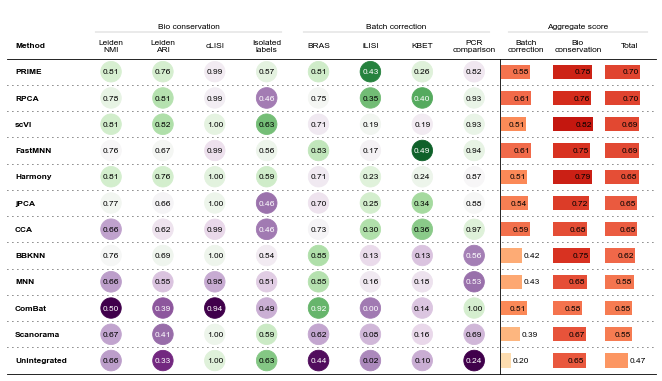

In [3]:
# scIB results table of pipeline/benchmark/immune/integrate_and_benchmark.py (scIB metrics + isolated-label score),
# drawn with the table function of that script (figlib/scib_table.py).
from figlib.scib_table import ISOLATED_LABELS_COL, plot_scib_results_table_repro

mpl.rcdefaults()
results_df = names.rename_methods(pd.read_csv(BENCH["immune"]["results_csv"], index_col=0))
col = results_df.pop(ISOLATED_LABELS_COL)            # isolated labels as the fourth column
results_df.insert(3, ISOLATED_LABELS_COL, col)
out = config.figure_dir("immune") / "benchmark_results_table.pdf"
with mpl.rc_context({"pdf.fonttype": 42, "ps.fonttype": 42, "font.family": "Arial", "figure.dpi": 300}):
    fig, ax, table = plot_scib_results_table_repro(results_df, cell_cmap=mpl.cm.PRGn, score_cmap=mpl.cm.OrRd,
                                                   sort_col="Total", figsize=(14, 8), show=False, save_path=None)
    fig.savefig(out, format="pdf", bbox_inches="tight", pad_inches=0.02)
print("wrote", rel(out))
preview(fig)

## UMAP of every method

In [4]:
# UMAP panels: one points-only PNG per method and colour (batch, cell type), as in
# pipeline/benchmark/immune/integrate_and_benchmark.py: 15 neighbours on all dimensions of the embedding,
# UMAP min_dist = 0.3, spread = 1.0 (scVI and BBKNN: scanpy defaults), PNG at 900 dpi.
from figlib.umap_png import save_method_umap_pngs

mpl.rcdefaults()
plt.rcParams["font.size"] = 16
UMAP_DIR = config.figure_dir("immune", "umap_plots")
CACHE = config.cache_dir("immune")


def umap_of(adata, key, name, **umap_kw):
    """UMAP coordinates of obsm[key]; cached in figures/_cache/immune/<name>.npy."""
    f = CACHE / f"{name}.npy"
    if not f.exists():
        sc.pp.neighbors(adata, use_rep=key)
        sc.tl.umap(adata, **umap_kw)
        np.save(f, adata.obsm["X_umap"])
    return np.load(f)


PAPER = dict(min_dist=0.3, spread=1.0)
METHODS = [("Unintegrated", "unintegrated", PAPER), ("Scanorama", "scanorama", PAPER), ("Harmony", "harmony", PAPER),
           ("MNN", "mnn", PAPER), ("ComBat", "combat", PAPER), ("scVI", "scvi", {}), ("PRIME", "prime", PAPER),
           ("CCA", "cca", PAPER), ("FastMNN", "fastmnn", PAPER), ("jPCA", "jpca", PAPER), ("RPCA", "rpca", PAPER)]
for key, slug, kw in METHODS:
    adata.obsm["X_umap"] = umap_of(adata, key, slug, **kw)
    save_method_umap_pngs(adata, data_path=UMAP_DIR, method_slug=slug, png_dpi=900, colors=("batch", "cell_type"))
    print("wrote", slug)

wrote unintegrated


wrote scanorama


wrote harmony


wrote mnn


wrote combat


...

wrote prime


wrote cca


wrote fastmnn


wrote jpca


wrote rpca


prime_umap_batch.png


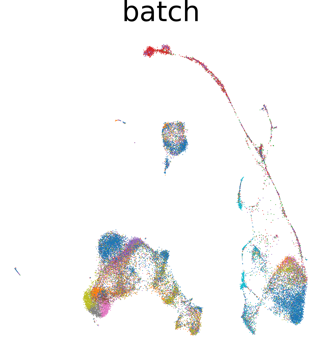

prime_umap_cell_type.png


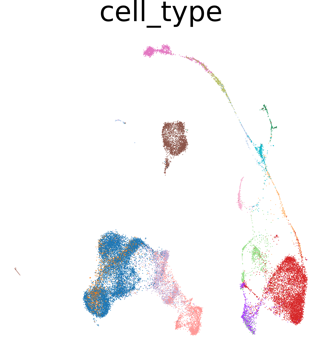

In [5]:
# BBKNN is a graph method: batch-balanced kNN graph on the PCA (50 components) of the 2,000 HVGs, then UMAP.
import bbknn

hv = adata.var["highly_variable"].to_numpy()
ad_bb = sc.AnnData(X=adata.X[:, hv].copy(), obs=adata.obs.copy(),
                   uns={k: v for k, v in adata.uns.items() if k.endswith("_colors")})
f = CACHE / "bbknn.npy"
if not f.exists():
    sc.pp.pca(ad_bb)
    bbknn.bbknn(ad_bb, batch_key="batch", neighbors_within_batch=3)
    sc.tl.umap(ad_bb)
    np.save(f, ad_bb.obsm["X_umap"])
ad_bb.obsm["X_umap"] = np.load(f)
save_method_umap_pngs(ad_bb, data_path=UMAP_DIR, method_slug="bbknn", png_dpi=900, colors=("batch", "cell_type"))
del ad_bb
show_png(UMAP_DIR / "prime_umap_batch.png", UMAP_DIR / "prime_umap_cell_type.png", max_px=350)

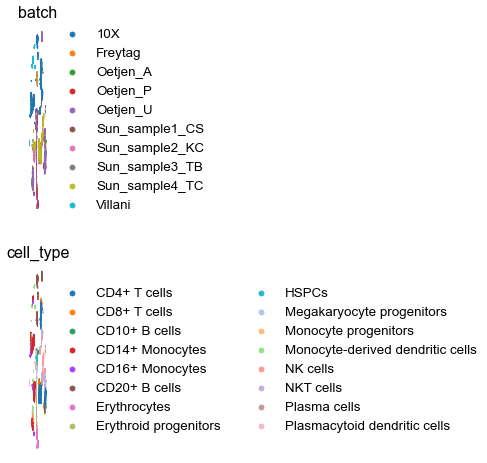

In [6]:
# Unintegrated UMAP with legends (unintegrated_umap_combined.pdf)
adata.obsm["X_umap"] = umap_of(adata, "Unintegrated", "unintegrated", **PAPER)
with plt.rc_context({"figure.dpi": 300, "pdf.fonttype": 42, "ps.fonttype": 42, "font.family": "Arial"}):
    fig, ax = plt.subplots(2, 1, figsize=(8, 8))
    sc.pl.umap(adata, color=["batch"], wspace=0.3, frameon=False, ncols=1, show=False, ax=ax[0])
    sc.pl.umap(adata, color=["cell_type"], wspace=0.3, frameon=False, ncols=1, show=False, ax=ax[1])
    plt.tight_layout()
    plt.savefig(UMAP_DIR / "unintegrated_umap_combined.pdf", bbox_inches="tight", pad_inches=0.02)
preview(fig)

## scGPT (zero-shot)

scGPT (whole-human checkpoint) applied zero-shot to the same 2,000 HVGs and scored with the protocol of the table above
(`pipeline/scgpt_zeroshot/`).

wrote figures/immune/benchmark_results_table_with_scgpt.pdf


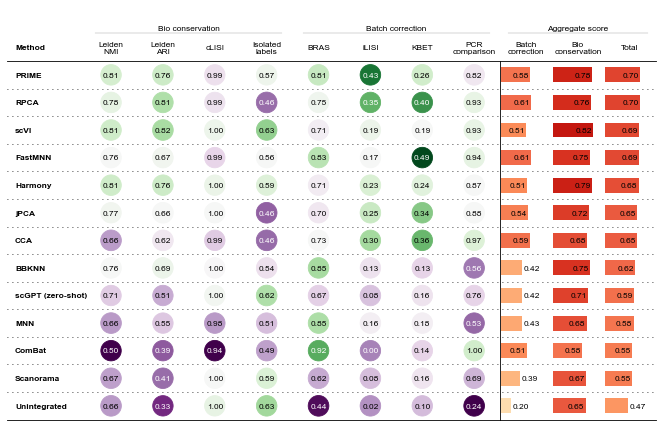

In [7]:
# The benchmark table with scGPT added. The rows of the other methods are the saved ones, unchanged; the scGPT row was
# scored by pipeline/scgpt_zeroshot/score_embeddings.py under the same protocol (scib-metrics, Leiden NMI / ARI, cLISI,
# BRAS, iLISI, kBET, PCR comparison, isolated-label silhouette; Total = 0.6 Bio + 0.4 Batch) and merged by
# collect_tables.py. scGPT (zero-shot): the pre-trained whole-human model applied as it is (no training, no batch
# information) to the same 2,000 HVGs as every other method.
SCGPT_DIR = CFG["out_dir"] / "scgpt" / "immune"
mpl.rcdefaults()
results_df = names.rename_methods(pd.read_csv(SCGPT_DIR / "scores" / "benchmark_results_with_scgpt.csv", index_col=0))
col = results_df.pop(ISOLATED_LABELS_COL)
results_df.insert(3, ISOLATED_LABELS_COL, col)
out = config.figure_dir("immune") / "benchmark_results_table_with_scgpt.pdf"
with mpl.rc_context({"pdf.fonttype": 42, "ps.fonttype": 42, "font.family": "Arial", "figure.dpi": 300}):
    fig, ax, table = plot_scib_results_table_repro(results_df, cell_cmap=mpl.cm.PRGn, score_cmap=mpl.cm.OrRd,
                                                   sort_col="Total", figsize=(14, 9), show=False, save_path=None)
    fig.savefig(out, format="pdf", bbox_inches="tight", pad_inches=0.02)
print("wrote", rel(out))
preview(fig)

wrote scgpt_zeroshot


scgpt_zeroshot_umap_batch.png


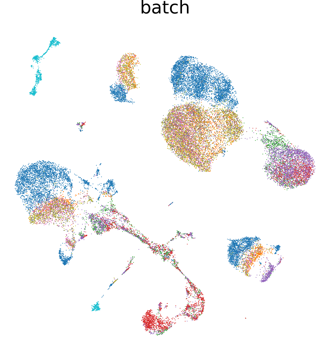

scgpt_zeroshot_umap_cell_type.png


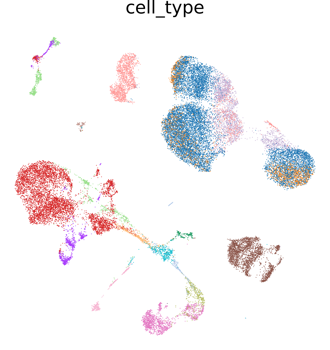

In [8]:
# UMAPs of the scGPT embeddings (pipeline/scgpt_zeroshot/embedding_umap.py: same settings as the other methods of this
# notebook), drawn with the same PNG function; coordinates are read from the saved results.
SCGPT_RUNS = [("scGPT_zeroshot_hvg", "scgpt_zeroshot")]
for name, slug in SCGPT_RUNS:
    f = SCGPT_DIR / "umap" / f"{name}.npy"
    if not f.exists():
        print("missing", f.name)
        continue
    adata.obsm["X_umap"] = np.load(f)
    save_method_umap_pngs(adata, data_path=UMAP_DIR, method_slug=slug, png_dpi=900, colors=("batch", "cell_type"))
    print("wrote", slug)
show_png(UMAP_DIR / "scgpt_zeroshot_umap_batch.png", UMAP_DIR / "scgpt_zeroshot_umap_cell_type.png", max_px=350)

## Cell-type markers

immune_markers_dotplot.png


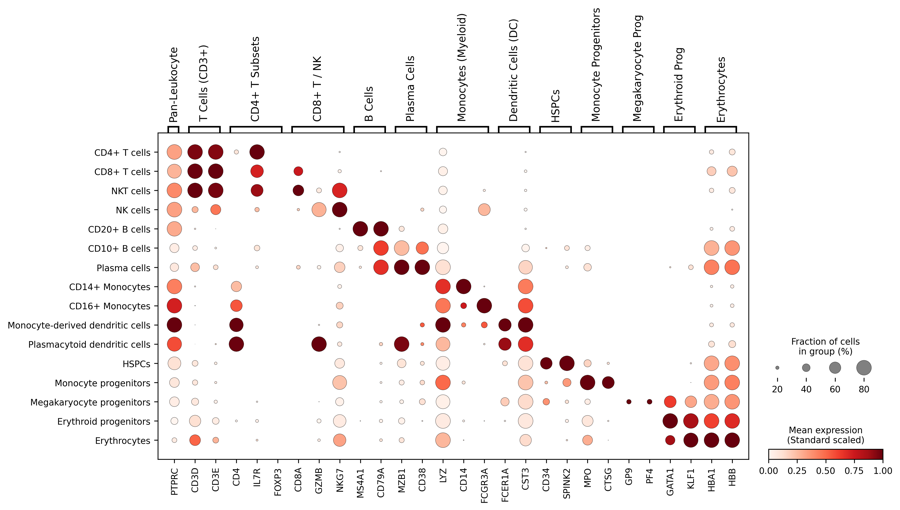

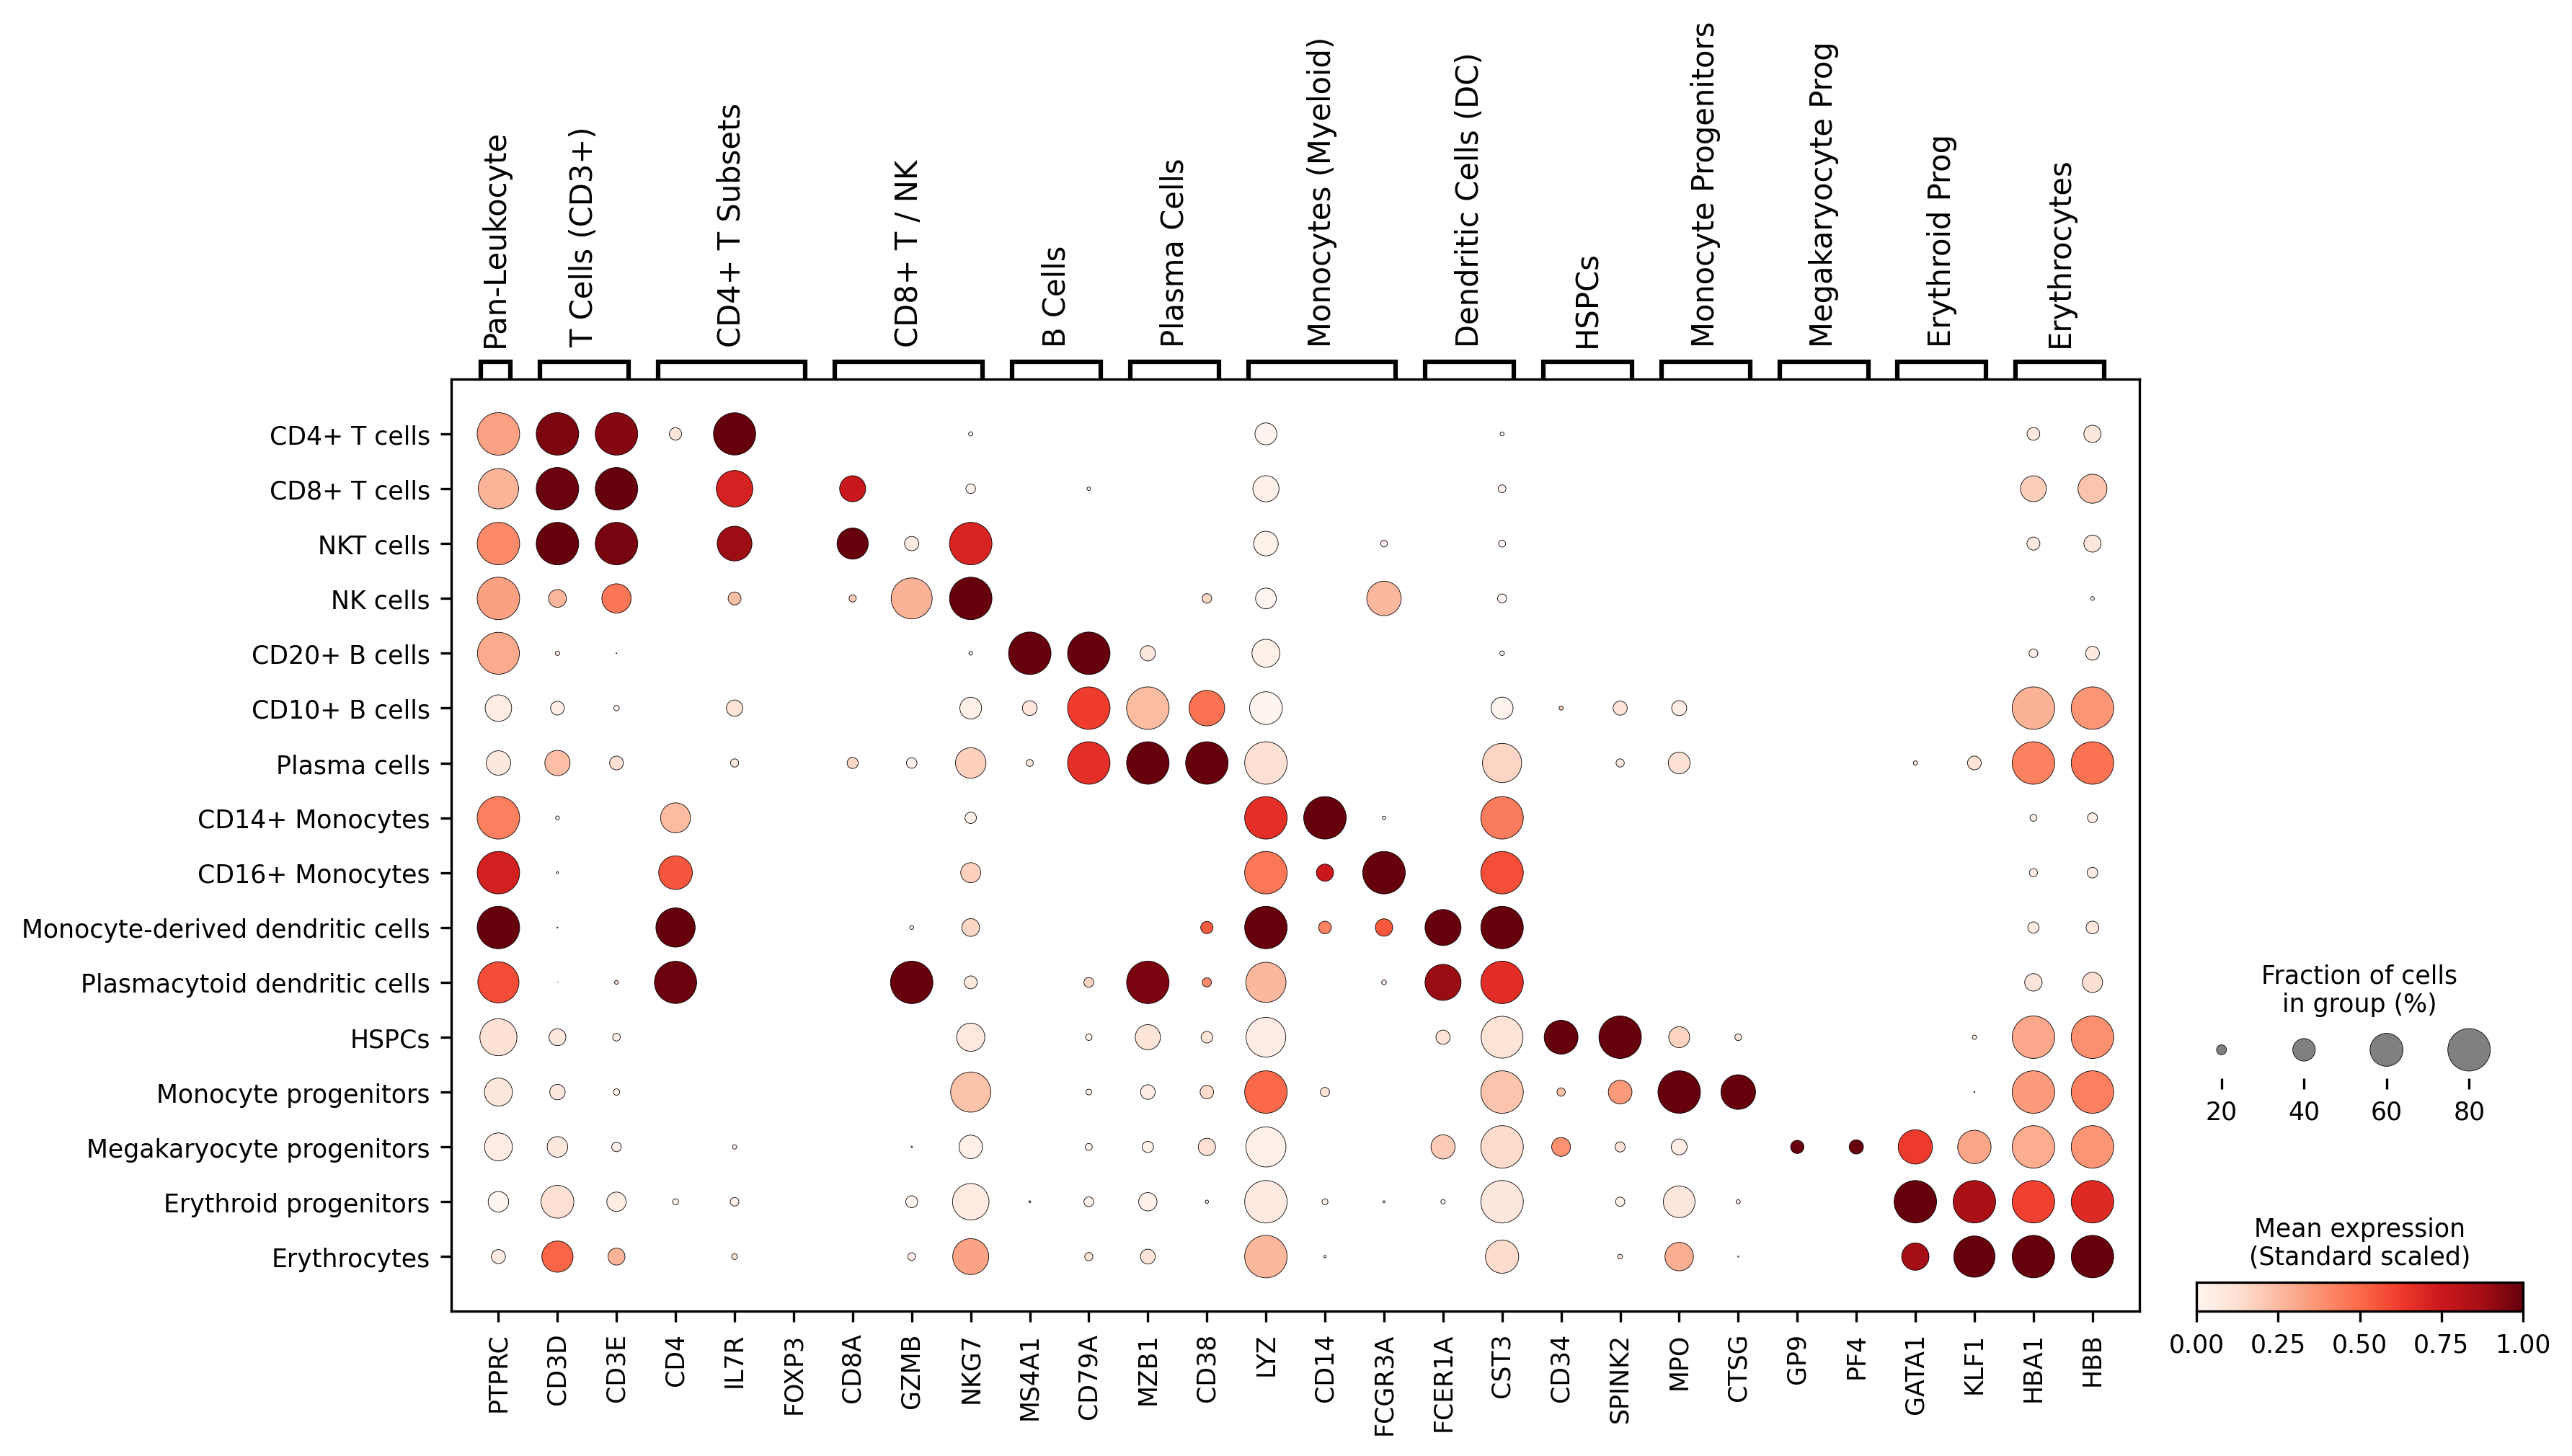

In [9]:
# Marker dot plot
mpl.rcdefaults()
marker_genes = {
    'Pan-Leukocyte': ['PTPRC'],
    'T Cells (CD3+)': ['CD3D', 'CD3E'],
    'CD4+ T Subsets': ['CD4', 'IL7R', 'FOXP3'],
    'CD8+ T / NK': ['CD8A', 'GZMB', 'NKG7'],
    'B Cells': ['MS4A1', 'CD79A'],
    'Plasma Cells': ['MZB1', 'CD38'],
    'Monocytes (Myeloid)': ['LYZ', 'CD14', 'FCGR3A'],
    'Dendritic Cells (DC)': ['FCER1A', 'CST3'],
    'HSPCs': ['CD34', 'SPINK2'],
    'Monocyte Progenitors': ['MPO', 'CTSG'],
    'Megakaryocyte Prog': ['GP9', 'PF4'],
    'Erythroid Prog': ['GATA1', 'KLF1'],
    'Erythrocytes': ['HBA1', 'HBB']
}
optimized_cell_order = [
    'CD4+ T cells', 'CD8+ T cells', 'NKT cells', 'NK cells',
    'CD20+ B cells', 'CD10+ B cells', 'Plasma cells',
    'CD14+ Monocytes', 'CD16+ Monocytes', 'Monocyte-derived dendritic cells', 'Plasmacytoid dendritic cells',
    'HSPCs', 'Monocyte progenitors', 'Megakaryocyte progenitors', 'Erythroid progenitors', 'Erythrocytes'
]
ad_dot = sc.AnnData(X=adata.X, obs=adata.obs.copy(), var=adata.var)      # the order below changes obs only
ad_dot.obs['cell_type'] = pd.Categorical(ad_dot.obs['cell_type'], categories=optimized_cell_order, ordered=True)
with plt.rc_context({'figure.dpi': 300, 'figure.figsize': (10, 5)}):
    ax = sc.pl.dotplot(
            ad_dot,
            var_names=marker_genes,
            groupby='cell_type',
            cmap='Reds',
            standard_scale='var',
            dot_max=0.8,
            dot_min=0.1,
            title=' ',
            colorbar_title='Mean expression\n(Standard scaled)',
            size_title='Fraction of cells\nin group (%)',
            return_fig=True
        )
    ax.savefig(config.figure_dir("immune") / 'immune_markers_dotplot.png', bbox_inches='tight')
show_png(config.figure_dir("immune") / 'immune_markers_dotplot.png', max_px=900)

UMAP_FeaturePlot_CD34.png


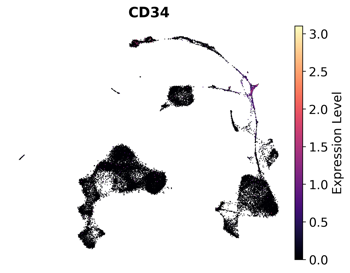

UMAP_FeaturePlot_HBB.png


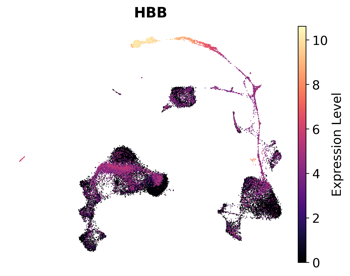

In [10]:
# Marker feature plots on the PRIME UMAP
mpl.rcdefaults()
ad_feat = sc.AnnData(X=adata.X, obs=ad_dot.obs.copy(), var=adata.var, obsm={"PRIME": adata.obsm["PRIME"]})
f = CACHE / "prime_featureplot_umap.npy"
if not f.exists():
    sc.pp.neighbors(ad_feat, use_rep='PRIME', n_neighbors=15)
    sc.tl.umap(ad_feat, min_dist=0.3, spread=1.0, random_state=42)
    np.save(f, ad_feat.obsm["X_umap"])
ad_feat.obsm["X_umap"] = np.load(f)

FONT_SIZE = 16
SAVE_DPI = 300
COLOR_MAP = 'magma'
OUTPUT_DIR = config.figure_dir("immune", "umap_feature_plots")
unique_markers = list(dict.fromkeys(g for genes in marker_genes.values() for g in genes))
for gene in unique_markers:
    if gene not in ad_feat.var_names:
        print(f"{gene} not in var_names; skipped")
        continue
    plt.close('all')
    with plt.rc_context({'figure.dpi': SAVE_DPI}):
        ax = sc.pl.umap(ad_feat, color=gene, cmap=COLOR_MAP, use_raw=False, frameon=False, show=False)
        ax.set_title(f'{gene}', fontsize=FONT_SIZE, fontweight='bold', pad=10)
        fig = ax.get_figure()
        if len(fig.axes) > 1:
            cbar_ax = fig.axes[-1]
            cbar_ax.tick_params(labelsize=FONT_SIZE - 2)
            cbar_ax.set_ylabel('Expression Level', fontsize=FONT_SIZE - 2)
        safe_gene_name = gene.replace('/', '_').replace('+', 'pos')
        plt.savefig(OUTPUT_DIR / f'UMAP_FeaturePlot_{safe_gene_name}.png', dpi=SAVE_DPI, bbox_inches='tight',
                    facecolor='white')
        plt.close(fig)
show_png(OUTPUT_DIR / "UMAP_FeaturePlot_CD34.png", OUTPUT_DIR / "UMAP_FeaturePlot_HBB.png", max_px=350)

supplementary_cell_cycle_umap.png


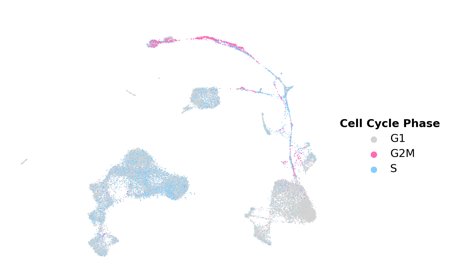

In [11]:
# Cell-cycle phase on the PRIME UMAP
FONT_SIZE = 12
TITLE_SIZE = 14
s_genes = [
    'MCM5', 'PCNA', 'TYMS', 'FEN1', 'MCM2', 'MCM4', 'RRM1', 'UNG', 'GINS2',
    'MCM6', 'CDCA7', 'DTL', 'PRIM1', 'UHRF1', 'MLF1IP', 'HELLS', 'RFC2',
    'RPA2', 'NASP', 'RAD51AP1', 'GMNN', 'WDR76', 'SLBP', 'CCNE2', 'UBR7',
    'POLD3', 'MSH2', 'ATAD2', 'RAD51', 'RRM2', 'CDC45', 'CDC6', 'EXO1',
    'TIPIN', 'DSCC1', 'BLM', 'CASP8AP2', 'USP1', 'CLSPN', 'CHAF1B', 'BRCA1',
    'BRCA2', 'BRIP1', 'FANCI', 'FANCD2', 'RAD51C', 'NBN', 'WRN', 'RECQL4'
]
g2m_genes = [
    'HMGB2', 'CDK1', 'NUSAP1', 'UBE2C', 'BIRC5', 'TPX2', 'TOP2A', 'NDC80',
    'CKS2', 'NUF2', 'CKS1B', 'MKI67', 'TMPO', 'CENPF', 'TACC3', 'FAM64A',
    'SMC4', 'CCNB2', 'CKAP2L', 'CKAP2', 'AURKB', 'BUB1', 'KIF11', 'ANP32E',
    'TUBB4B', 'GTSE1', 'KIF20B', 'HJURP', 'CDCA3', 'HN1', 'CDC20', 'TTK',
    'CDC25C', 'KIF2C', 'E2F8', 'PLK1', 'ECT2', 'PRC1', 'CDCA8', 'CCNBA',
    'CENPE', 'CENPA', 'NZF1', 'LBR', 'KIF4A', 'DEPDC1', 'SMC2', 'NUDT15'
]
s_genes = [g for g in s_genes if g in ad_feat.var_names]
g2m_genes = [g for g in g2m_genes if g in ad_feat.var_names]
sc.tl.score_genes_cell_cycle(ad_feat, s_genes=s_genes, g2m_genes=g2m_genes)
plt.close('all')
with plt.rc_context({'figure.dpi': SAVE_DPI}):
    ax = sc.pl.umap(ad_feat, color='phase', palette={'G1': '#d3d3d3', 'S': '#87cefa', 'G2M': '#ff69b4'},
                    frameon=False, show=False)
    ax.set_title(' ', fontsize=TITLE_SIZE, fontweight='bold', pad=10)
    fig = ax.get_figure()
    leg = ax.get_legend()
    if leg:
        plt.setp(leg.get_texts(), fontsize=FONT_SIZE)
        leg.set_title('Cell Cycle Phase', prop={'size': FONT_SIZE, 'weight': 'bold'})
    plt.savefig(OUTPUT_DIR / 'supplementary_cell_cycle_umap.png', dpi=SAVE_DPI, bbox_inches='tight', facecolor='white')
    plt.close(fig)
show_png(OUTPUT_DIR / 'supplementary_cell_cycle_umap.png', max_px=450)

## Haematopoietic trajectory

In [12]:
# Monocle3 trajectories (R; pipeline/trajectory/trajectory_panels.R) on the saved UMAP of each method
# (Immune_ALL_human_<method>_umap.npy, written by pipeline/benchmark/immune/integrate_and_benchmark.py).
import shutil
import subprocess

TRAJ_DIR = config.figure_dir("immune", "trajectory")
TRAJ_METHODS = ["PRIME", "Unintegrated", "Scanorama", "Harmony", "MNN"]
IMMUNE_DIR = Path(BENCH["immune"]["dir"])
UMAP_DIR_SAVED = config.cache_dir("immune", "trajectory_umaps")       # one folder with the UMAP of every method
for m in TRAJ_METHODS:
    name = "Immune_ALL_human_{method}_umap.npy"
    src = next((f for f in (names.method_file(str(d / name), m.lower()) for d in (IMMUNE_DIR / "umap_embeddings", IMMUNE_DIR))
                if f.exists()), None)
    assert src is not None, f"no saved UMAP for {m}"
    shutil.copyfile(src, UMAP_DIR_SAVED / name.format(method=m.lower()))
todo = [m for m in TRAJ_METHODS if not (TRAJ_DIR / m / "cell_type_embedding.pdf").exists()]
if todo:
    cmd = [CFG["rscript"], str(config.ROOT / "pipeline/trajectory/trajectory_panels.R"),
           str(BENCH["immune"]["embeddings_h5ad"]), str(UMAP_DIR_SAVED), str(TRAJ_DIR), *todo]
    r = subprocess.run(cmd, capture_output=True, text=True)
    print(r.stderr[-3000:])
    r.check_returncode()
for m in TRAJ_METHODS:
    print(m, sorted(p.name for p in (TRAJ_DIR / m).glob("*")))

PRIME ['cds_colData_with_pseudotime.csv', 'cell_type_embedding.pdf', 'pseudotime_embedding.pdf']
Unintegrated ['cds_colData_with_pseudotime.csv', 'cell_type_embedding.pdf', 'pseudotime_embedding.pdf']
Scanorama ['cds_colData_with_pseudotime.csv', 'cell_type_embedding.pdf', 'pseudotime_embedding.pdf']
Harmony ['cds_colData_with_pseudotime.csv', 'cell_type_embedding.pdf', 'pseudotime_embedding.pdf']
MNN ['cds_colData_with_pseudotime.csv', 'cell_type_embedding.pdf', 'pseudotime_embedding.pdf']


[INFO] adata.X check passed (max=10.1778, likely normalized).
[INFO] erythroid: retained 2438 cells after cell-type filtering.
[INFO] Proceeding with 2438 cells for trajectory validation.

[INFO] Stage-order table:
            cell_type  stage_rank  n_cells  median_pseudotime  mean_pseudotime
                HSPCs           1      473           0.467428         0.864376
Erythroid progenitors           2      462           3.391034         3.587022
         Erythrocytes           3     1498           8.180505         7.408535

[INFO] Stage-order summary:
                 metric  spearman_rho  spearman_p  kendall_tau  kendall_p
stage_order_consistency           1.0         0.0          1.0   0.333333

[INFO] Module trend summary:
            module  n_genes_present  median_signed_spearman_rho  median_signed_kendall_tau  mean_signed_spearman_rho  mean_signed_kendall_tau
     stemness_down                8                    0.306153                   0.246303                  0.330589    

[WARNING] Representative gene 'ALAS2' not found in adata.var_names; skipping plot.
[WARNING] Representative gene 'GYPA' not found in adata.var_names; skipping plot.


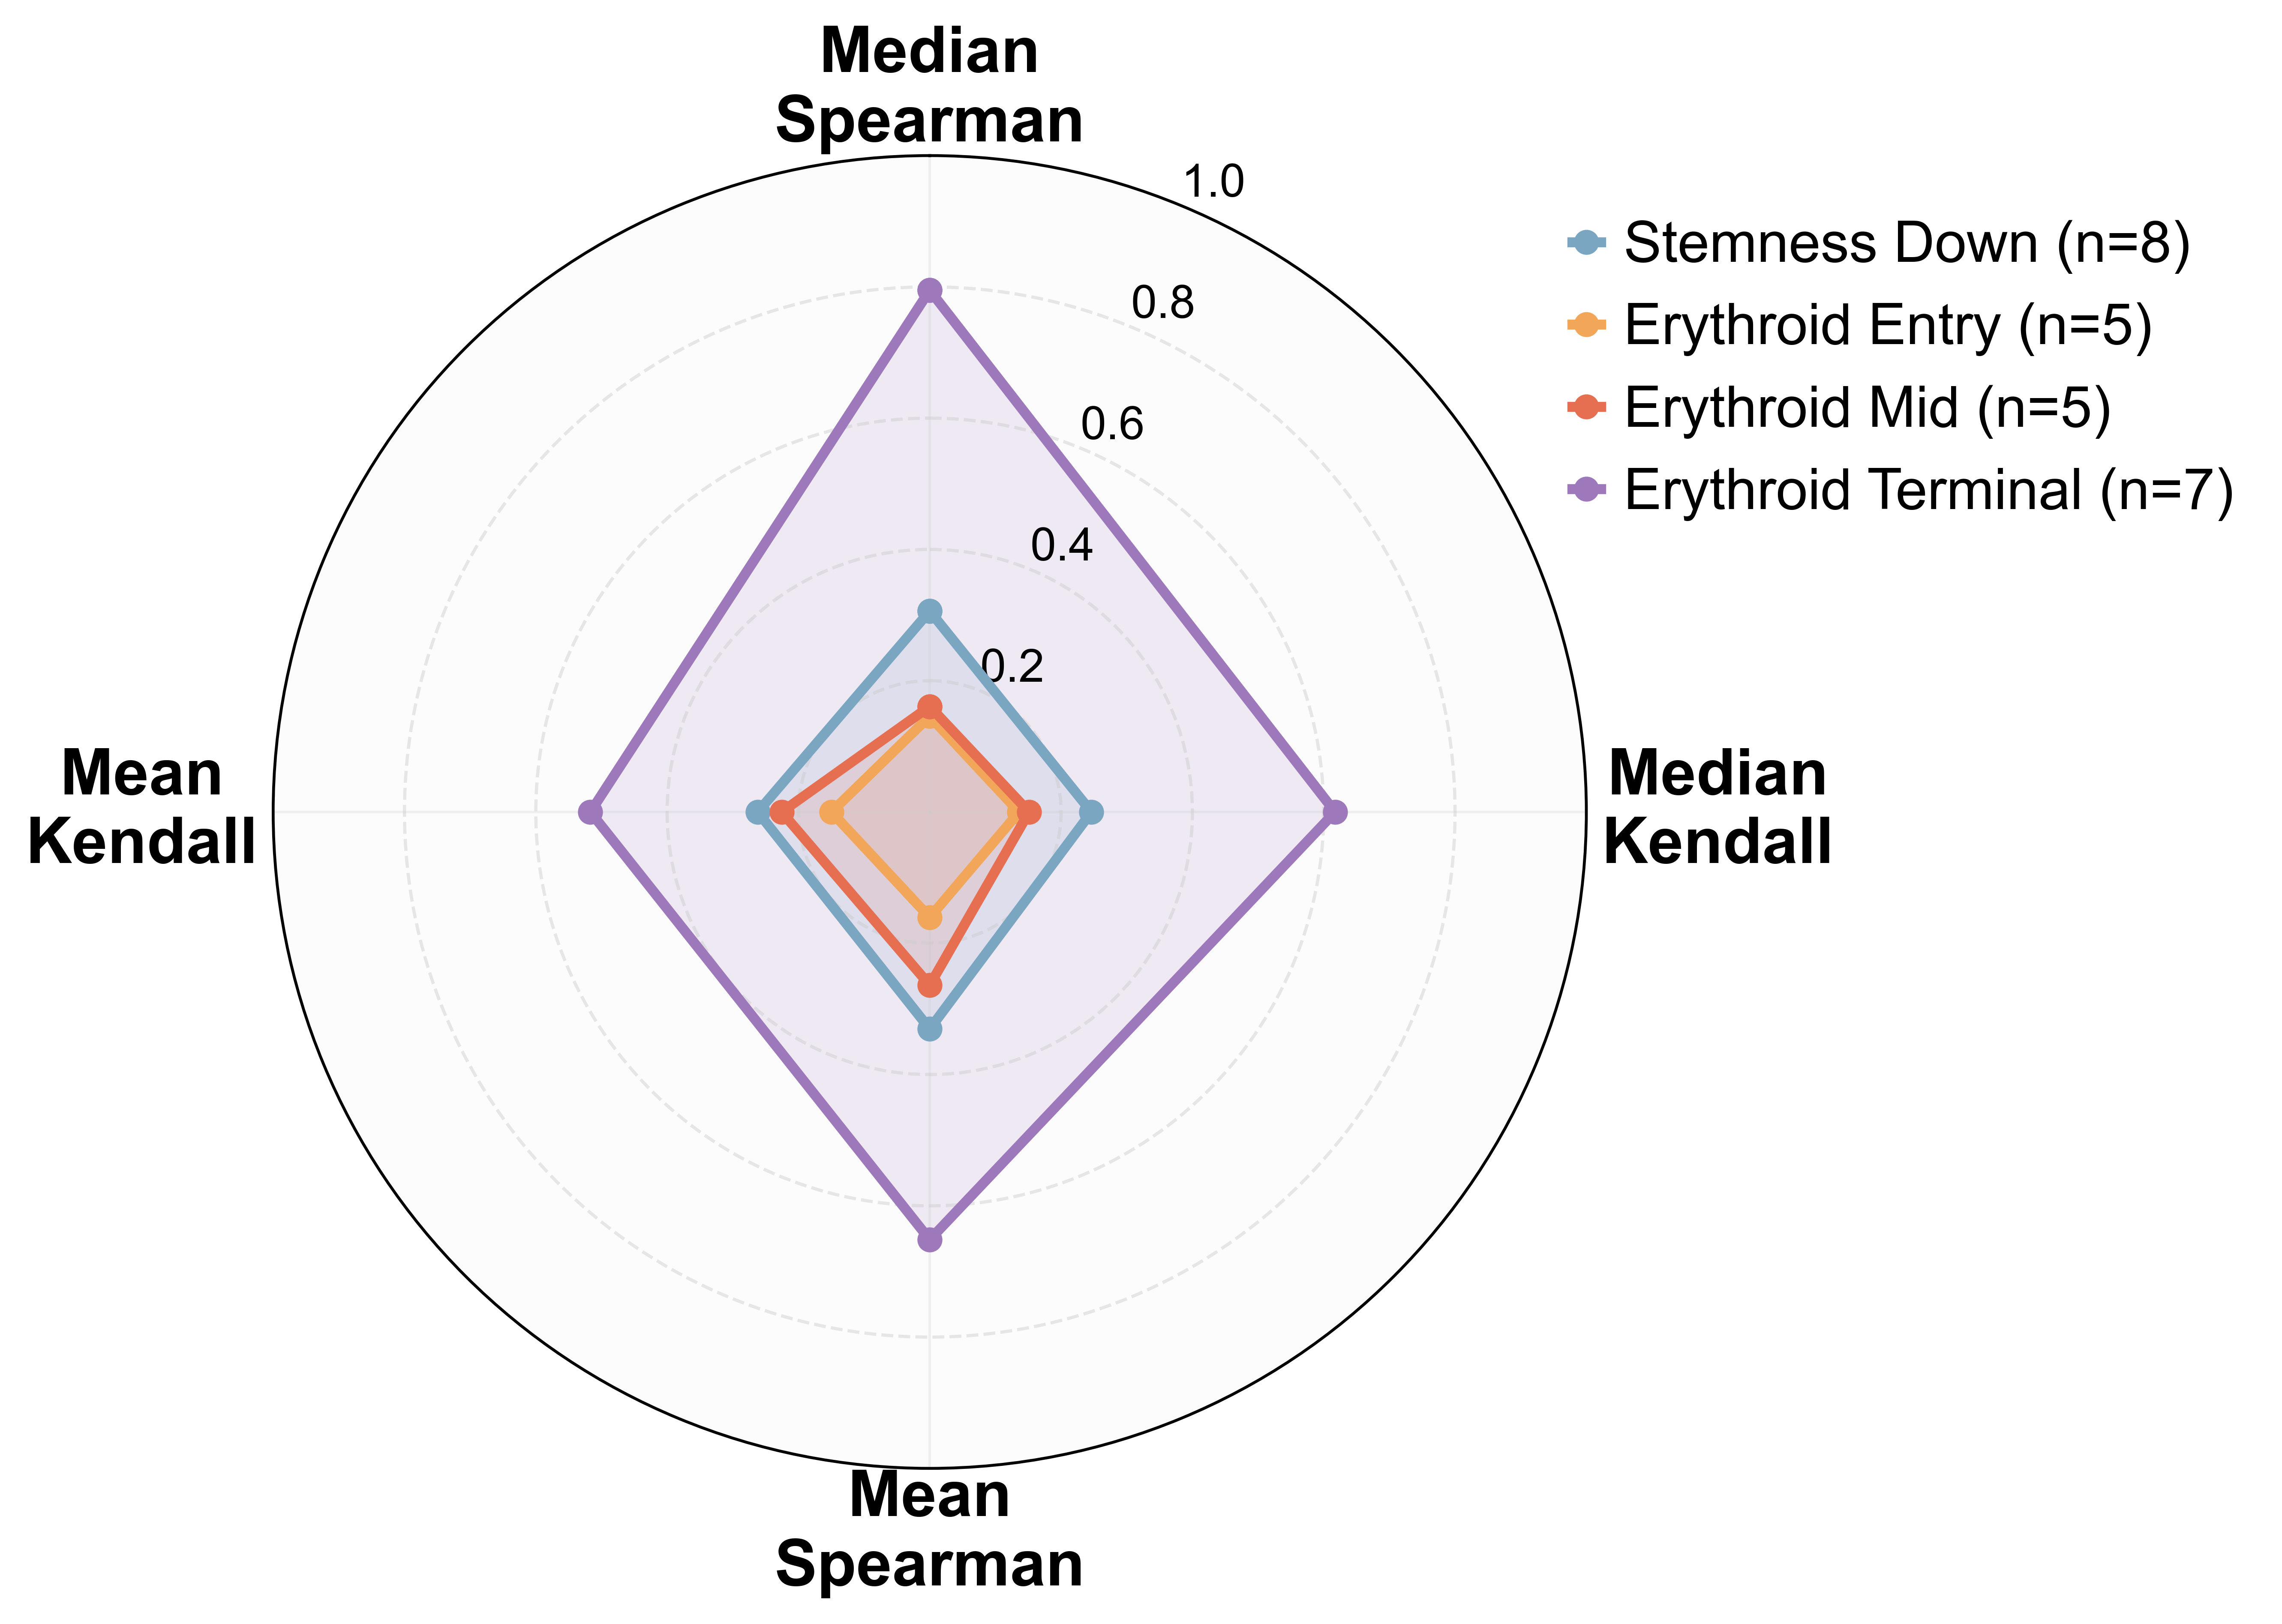

[INFO] adata.X check passed (max=10.1778, likely normalized).
[INFO] monocyte: retained 8381 cells after cell-type filtering.
[INFO] Proceeding with 8381 cells for trajectory validation.



[INFO] Stage-order table:
           cell_type  stage_rank  n_cells  median_pseudotime  mean_pseudotime
               HSPCs           1      473           0.467428         0.864376
Monocyte progenitors           2      428           0.357677         0.635988
     CD14+ Monocytes           3     6483           6.712022         6.245707
     CD16+ Monocytes           4      997          11.896972        11.417129

[INFO] Stage-order summary:
                 metric  spearman_rho  spearman_p  kendall_tau  kendall_p
stage_order_consistency           0.8         0.2     0.666667   0.333333

[INFO] Module trend summary:
         module  n_genes_present  median_signed_spearman_rho  median_signed_kendall_tau  mean_signed_spearman_rho  mean_signed_kendall_tau
  stemness_down                8                    0.167664                   0.135015                  0.196751                 0.158643
  myeloid_entry                7                   -0.257217                  -0.205686           

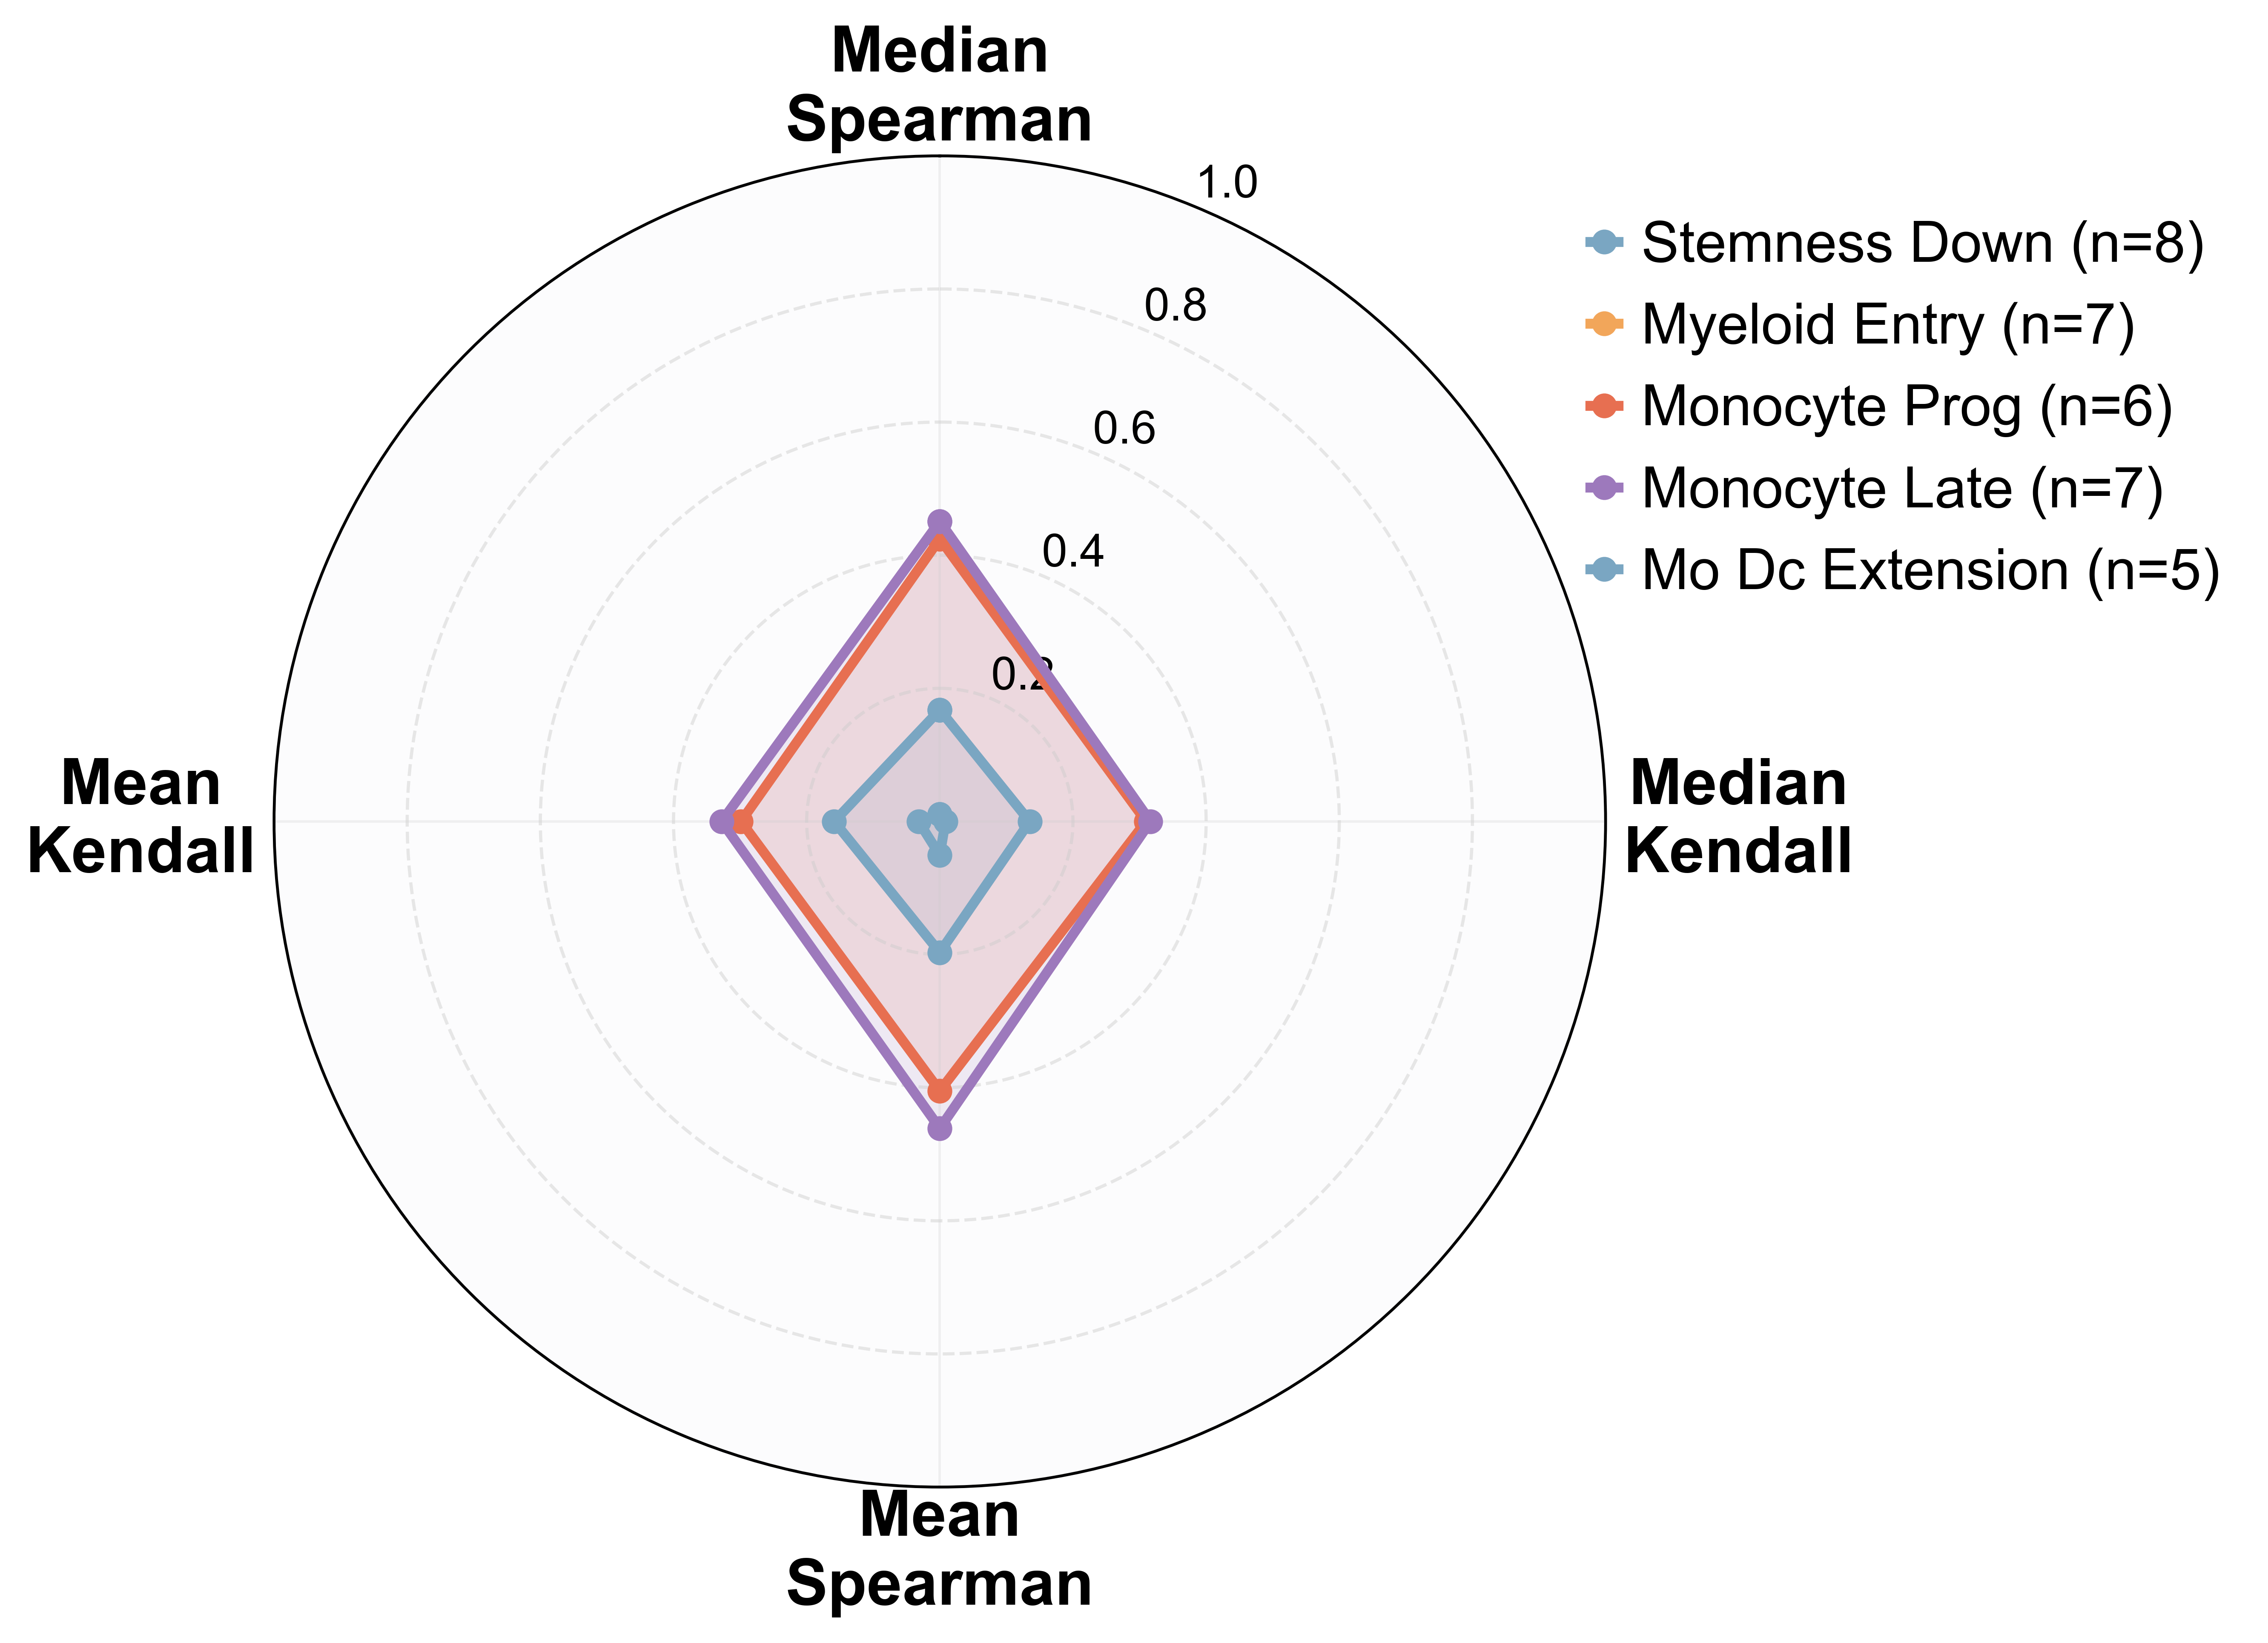

['CSF3R_monocyte_pseudotime_trend.pdf', 'EPOR_erythroid_pseudotime_trend.pdf', 'FCER1A_monocyte_pseudotime_trend.pdf', 'FCER1G_monocyte_pseudotime_trend.pdf', 'FCN1_monocyte_pseudotime_trend.pdf', 'HBA1_erythroid_pseudotime_trend.pdf', 'HBB_erythroid_pseudotime_trend.pdf', 'HLF_erythroid_pseudotime_trend.pdf', 'HLF_monocyte_pseudotime_trend.pdf', 'KLF1_erythroid_pseudotime_trend.pdf', 'LST1_monocyte_pseudotime_trend.pdf', 'LYZ_monocyte_pseudotime_trend.pdf', 'MECOM_erythroid_pseudotime_trend.pdf', 'MECOM_monocyte_pseudotime_trend.pdf', 'S100A8_monocyte_pseudotime_trend.pdf', 'S100A9_monocyte_pseudotime_trend.pdf', 'TFRC_erythroid_pseudotime_trend.pdf', 'erythroid_module_trend_summary.pdf', 'monocyte_module_trend_summary.pdf']


In [13]:
# Marker genes along pseudotime, erythroid and monocyte lineages (figlib/trajectory_genes.py), with the pseudotime
# of the PRIME trajectory from the Monocle3 run above.
from figlib import trajectory_genes as TG

pseudotime_df = pd.read_csv(TRAJ_DIR / "PRIME" / "cds_colData_with_pseudotime.csv", index_col=0)
ad_traj = sc.AnnData(X=adata.X, obs=adata.obs.copy(), var=adata.var)
ad_traj.obs = ad_traj.obs.join(pseudotime_df[["pseudotime"]], how="left")
GENE_DIR = config.figure_dir("immune", "trajectory_genes")
for lineage in ("erythroid", "monocyte"):
    mpl.rcdefaults()
    sub, stage_df, stage_summary_df, gene_metric_df, module_metric_df = TG.analyse_lineage(ad_traj, lineage, GENE_DIR)
    TG.plot_gene_trends(sub, lineage, GENE_DIR)
    TG.plot_module_radar(module_metric_df, lineage, GENE_DIR)
sc.settings.set_figure_params(dpi=80)      # the trend plots set scanpy to 600 dpi; back to screen resolution
print(sorted(p.name for p in GENE_DIR.glob("*.pdf")))

## Parameter sensitivity, trajectory comparison and scGPT summary

Drawn from the result tables under `out_dir` of the pipeline configuration.

In [14]:
# Style and helpers of the analysis figures (figlib/style.py): palette, save, panel, load, sweep, ...
# OUT = out_dir of the pipeline configuration (result tables); figures are written to figures/immune/.
import figlib.style as S
from figlib.style import *          # CFG, OUT, C (pipeline/common.py), palette, save, panel, load, sweep, ...
S.set_figure_dir(config.figure_dir("immune"))


def draw(fn, name):
    S.apply_style()
    fn()
    png = S.FIG / f"{name}.png"
    if png.exists():
        show_png(png, max_px=1100)
    else:
        print(f"{name}: input tables not found under out_dir; figure skipped")

### Parameter sensitivity

PRIME on the human immune data, one factor at a time around the default setting: projections K, projection dimension
d, MNN neighbours k, consensus threshold τ, smoothing bandwidth σ.

In [15]:
SENS_PARAMS = {"n_projections": "Projections K", "target_dim": "Projection dim d", "k_neighbors": "MNN neighbours k",
             "consensus_threshold": "Consensus threshold τ", "sigma": "Smoothing σ"}


def fig_sensitivity_immune():
    """Parameter sensitivity of PRIME on the human immune data."""
    metrics = [("precision", "Anchor precision"), ("coverage", "Anchor coverage"),
               ("KMeans NMI", "KMeans NMI"), ("BRAS", "BRAS (batch)")]
    df = load("sensitivity/immune/results_task*.tsv")
    if df is None:
        return
    default = CFG["datasets"]["immune"]["default"]
    ref = pd.read_csv(OUT / "sensitivity/immune/unintegrated.tsv", sep="\t", index_col=0)
    fig, axes = plt.subplots(1, 5, figsize=(10.5, 2.5), sharey=True)
    for c, (p, lab) in enumerate(SENS_PARAMS.items()):
        ax = axes[c]
        sub = sweep(df, default, p)
        if p == "n_projections":
            sub = sub[sub["value"] != 5]           # K = 5 is not drawn (it sits next to the default K = 4)
        for (m, mlab), col in zip(metrics, SLOT):
            line_with_band(ax, sub, m, col, mlab)
        ax.axvline(default[p], color=INK2, lw=0.8, ls="--")
        ax.axhline(ref.loc["Unintegrated", "KMeans NMI"], color=SLOT[2], lw=0.8, ls=":")
        ax.axhline(ref.loc["Unintegrated", "BRAS"], color=SLOT[3], lw=0.8, ls=":")
        if p in ("n_projections", "target_dim"):
            plain_log_ticks(ax, sub["value"].unique(), base=2, keep=default[p])
        ax.set_xlabel(lab)
        ax.set_ylim(-0.02, 1.05)
        panel(ax, "abcde"[c])
    axes[0].set_ylabel("Score (human immune)")
    h, l = axes[-1].get_legend_handles_labels()
    h += [mpl.lines.Line2D([], [], color=INK2, ls="--", lw=0.8), mpl.lines.Line2D([], [], color=INK2, ls=":", lw=0.8)]
    l += ["default setting", "unintegrated (NMI, BRAS)"]
    fig.legend(h, l, loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=6)
    fig.tight_layout()
    save(fig, "sensitivity_immune")

wrote figures/immune/sensitivity_immune


sensitivity_immune.png


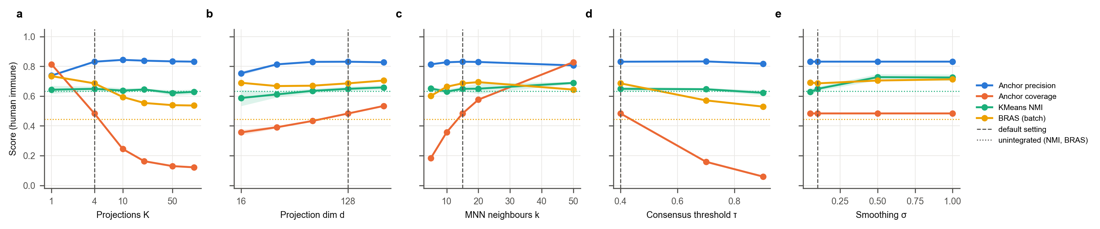

In [16]:
draw(fig_sensitivity_immune, "sensitivity_immune")

### Trajectory comparison

One Monocle3 pipeline for PRIME, Harmony and FastMNN: topology F1, stage order, cells reached from the root, marker
trends.

In [17]:
CMP_METHODS = [("PRIME", "PRIME"), ("Harmony", "Harmony"), ("FastMNN", "FastMNN")]


CMP_LIN = ["erythroid", "megakaryocyte", "monocyte"]


CMP_TYPES = {"HSPCs": "#e34948", "Erythroid progenitors": "#eb6834", "Erythrocytes": "#eda100",
            "Megakaryocyte progenitors": "#8a5a00", "Monocyte progenitors": "#1baf7a", "CD14+ Monocytes": "#008300",
            "CD16+ Monocytes": "#6fd08c"}


def fig_trajectory_comparison():
    main, sens = OUT / "trajectory/partitioned", OUT / "trajectory/one_graph"      # use_partition TRUE / FALSE
    if not (main / "metrics.tsv").exists() or not (sens / "metrics.tsv").exists():
        return
    nice = dict(CMP_METHODS)
    m = names.rename_methods(pd.read_csv(main / "metrics.tsv", sep="\t")).replace({"method": nice})
    ms = names.rename_methods(pd.read_csv(sens / "metrics.tsv", sep="\t")).replace({"method": nice})
    dyn = names.rename_methods(pd.read_csv(main / "marker_dynamics.tsv", sep="\t")).replace({"method": nice})
    order = ["FastMNN", "Harmony", "PRIME"]                                  # bottom to top
    fig = plt.figure(figsize=(12.5, 5.6))
    gs = fig.add_gridspec(2, 12, height_ratios=[1, 1.35], hspace=0.45, wspace=0.9)
    ax = fig.add_subplot(gs[0, 0:3])
    for y, meth in enumerate(order):
        a, b = m[m.method == meth]["topo_f1"], ms[ms.method == meth]["topo_f1"]
        col = SLOT[0] if meth == "PRIME" else INK
        ax.errorbar(a.mean(), y, xerr=a.std(), fmt="o", color=col, ms=5, lw=0.8, label="default partitions" if y == 0 else None)
        ax.errorbar(b.mean(), y, xerr=b.std(), fmt="o", mfc="white", color=col, ms=5, lw=0.8,
                    label="one graph (sensitivity)" if y == 0 else None)
    ax.set_yticks(range(len(order)), order)
    ax.set_ylim(-0.6, len(order) - 0.4)
    ax.set_xlim(0, 1)
    ax.set_xlabel("Topology F1 (ancestor relations)")
    ax.legend(loc="lower left", fontsize=5.5)
    ax.grid(axis="y", visible=False)
    panel(ax, "a")
    for sl, prefix, cols, title, cmap, lo, letter in (
            (slice(3, 6), "spearman_", CMP_LIN, "Pseudotime vs stage\n(Spearman)", DIV, -1, "b"),
            (slice(6, 10), "coverage_", CMP_LIN + ["off"], "Fraction of cells reached\nfrom the root", SEQ, 0, "c")):
        ax = fig.add_subplot(gs[0, sl])
        h = m.groupby("method")[[prefix + c if c != "off" else "off_lineage_reached" for c in cols]].mean().reindex(order[::-1])
        im = ax.imshow(h.values, cmap=cmap, vmin=lo, vmax=1, aspect="auto")
        for i in range(h.shape[0]):
            for j in range(h.shape[1]):
                v = h.iat[i, j]
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6,
                        color="white" if (prefix == "coverage_" and v > 0.7) or (prefix == "spearman_" and abs(v) > 0.7) else INK)
        ax.set_xticks(range(len(cols)), [c if c != "off" else "off-lineage\n(lower = better)" for c in cols],
                      rotation=30, ha="right")
        ax.set_yticks(range(h.shape[0]), h.index if letter == "b" else [])
        ax.set_title(title)
        ax.grid(False)
        panel(ax, letter)
    ax = fig.add_subplot(gs[0, 10:12])
    s = dyn.groupby("method")["sign_ok"].mean().reindex(order)
    ax.barh(range(len(order)), s.values, color=[SLOT[0] if i == "PRIME" else GREY for i in order], height=0.6)
    for y, v in enumerate(s.values):
        ax.text(v, y, f" {v:.2f}", va="center", fontsize=6)
    ax.set_yticks(range(len(order)), [])
    ax.set_xlim(0, 1.15)
    ax.set_xlabel("Marker trends with\nexpected direction")
    ax.grid(axis="y", visible=False)
    panel(ax, "d")
    for c, (key, meth) in enumerate(CMP_METHODS):
        u = pd.read_csv(names.method_file(str(main / "umap_{method}_s1.tsv.gz"), key), sep="\t")
        g = pd.read_csv(names.method_file(str(main / "graph_{method}_s1.tsv"), key), sep="\t")
        ax = fig.add_subplot(gs[1, 4 * c:4 * c + 4])
        ax.scatter(u.umap1, u.umap2, s=0.4, c="#dcdbd7", linewidths=0, rasterized=True)
        for t, col in CMP_TYPES.items():
            k = u.cell_type == t
            ax.scatter(u.umap1[k], u.umap2[k], s=4 if t == "HSPCs" else 1.2, c=col, linewidths=0, rasterized=True,
                       label=t, zorder=3 if t == "HSPCs" else 2)
        for e in g.itertuples():
            ax.plot([e.x1, e.x2], [e.y1, e.y2], color=INK, lw=0.4, zorder=4)
        rr = g[g.root]
        ax.scatter(np.r_[rr.x1, rr.x2], np.r_[rr.y1, rr.y2], marker="*", s=40, color="#e34948", edgecolor=INK,
                   lw=0.4, zorder=5)
        ax.set_title(meth, fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(False)
        for sp in ax.spines.values():
            sp.set_visible(False)
        ax.set_aspect("equal", adjustable="datalim")
        if c == 0:
            panel(ax, "e")
            ax.set_ylabel("cell types, principal graph and root (star)", fontsize=6.5)
    h = [mpl.lines.Line2D([], [], marker="o", ls="", color=col, ms=4, label=t) for t, col in CMP_TYPES.items()]
    h.append(mpl.lines.Line2D([], [], marker="o", ls="", color="#dcdbd7", ms=4, label="other cells (B, T, NK, DC)"))
    h.append(mpl.lines.Line2D([], [], marker="*", ls="", color="#e34948", markeredgecolor=INK, markeredgewidth=0.4, ms=7,
                              label="root"))
    fig.legend(handles=h, loc="upper center", bbox_to_anchor=(0.5, 0.06), ncol=9, fontsize=6)
    save(fig, "trajectory_comparison")

wrote figures/immune/trajectory_comparison


trajectory_comparison.png


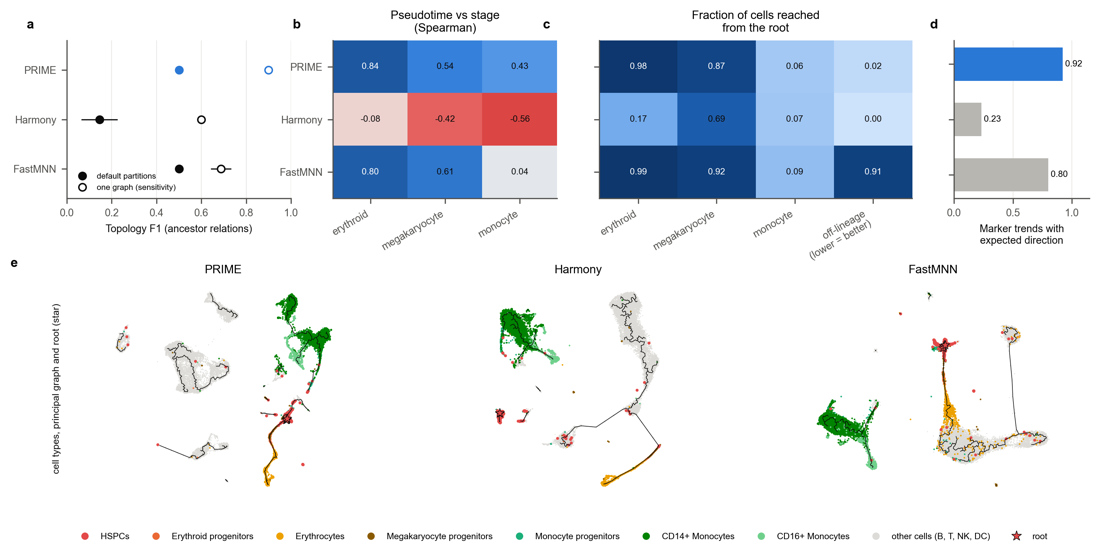

In [18]:
draw(fig_trajectory_comparison, "trajectory_comparison")

### Benchmark tables with scGPT

The benchmark tables of the human immune data (left) and the NSCLC lung-adenocarcinoma data (right) with scGPT
(zero-shot) added.

In [19]:
SCGPT_DATASETS = [("immune", "Human immune (33,506 cells, 10 batches)"), ("lung", "NSCLC lung adenocarcinoma (410,927 cells, 12 datasets)")]


SCGPT_METRICS = ["Leiden NMI", "Leiden ARI", "cLISI", "Isolated labels", "BRAS", "iLISI", "KBET", "PCR comparison",
              "Bio conservation", "Batch correction", "Total"]


SCGPT_NAMES: dict = {}          # display names that differ from the method key


def scgpt_table(ax, ds):
    """Benchmark table + scGPT row: methods sorted by Total, every column scaled to its own range."""
    df = names.rename_methods(pd.read_csv(OUT / "scgpt" / ds / "scores" / "benchmark_results_with_scgpt.csv", index_col=0))
    df = df.drop(index="Metric Type").astype(float).sort_values("Total", ascending=False)[SCGPT_METRICS]
    z = (df - df.min()) / (df.max() - df.min())
    ax.imshow(z.values, cmap=SEQ, aspect="auto", vmin=0, vmax=1.15)
    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            ax.text(j, i, f"{df.iloc[i, j]:.2f}", ha="center", va="center", fontsize=5.5, color="white" if z.iloc[i, j] > 0.62 else INK)
    ax.set_xticks(range(df.shape[1]), df.columns, rotation=45, ha="right", fontsize=6)
    ax.set_yticks(range(df.shape[0]), [SCGPT_NAMES.get(m, m) for m in df.index], fontsize=6.5)
    for tick, m in zip(ax.get_yticklabels(), df.index):
        if m == "PRIME":
            tick.set_color(SLOT[0]); tick.set_fontweight("bold")
        elif m.startswith("scGPT"):
            tick.set_color(SLOT[1]); tick.set_fontweight("bold")
    ax.axvline(7.5, color="white", lw=2.5)
    ax.grid(False)
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.tick_params(length=0)


def fig_scgpt_benchmark_tables():
    """The benchmark tables of both data sets with scGPT (zero-shot) added."""
    if not all((OUT / "scgpt" / ds / "scores" / "benchmark_results_with_scgpt.csv").exists() for ds, _ in SCGPT_DATASETS):
        return
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.9), gridspec_kw={"wspace": 0.42})
    for r, (ds, title) in enumerate(SCGPT_DATASETS):
        scgpt_table(axes[r], ds)
        axes[r].set_title(title, loc="left", fontsize=8)
        panel(axes[r], "ab"[r])
    save(fig, "scgpt_benchmark_tables")

wrote figures/immune/scgpt_benchmark_tables


scgpt_benchmark_tables.png


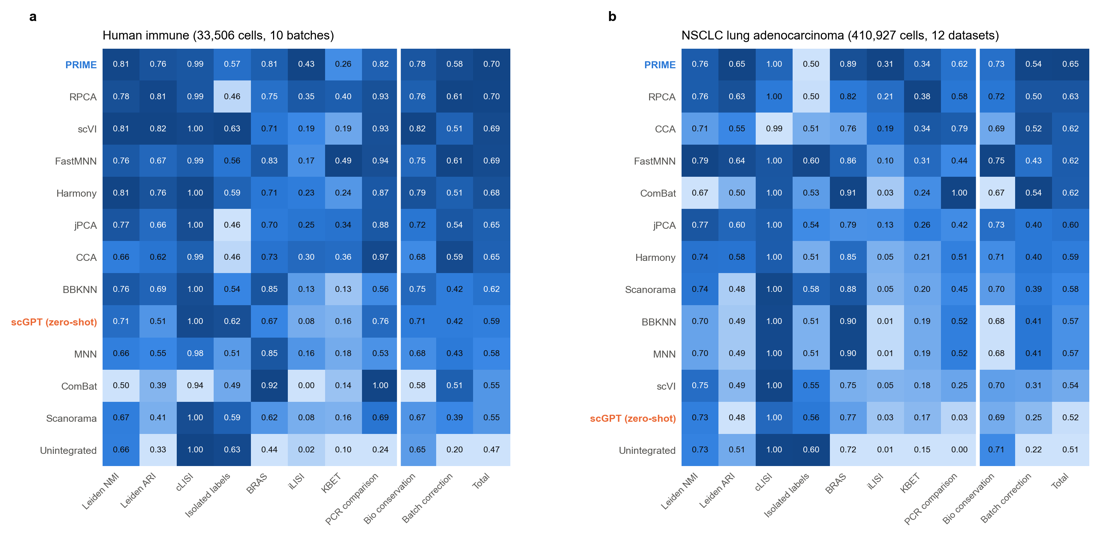

In [20]:
draw(fig_scgpt_benchmark_tables, "scgpt_benchmark_tables")

### UMAP of the scGPT embeddings

scGPT (zero-shot) embeddings of the human immune data (top) and the NSCLC lung-adenocarcinoma data (bottom), coloured
by batch and by cell type.

In [21]:
SCGPT_DATASETS = [("immune", "Human immune (33,506 cells, 10 batches)"), ("lung", "NSCLC lung adenocarcinoma (410,927 cells, 12 datasets)")]


SCGPT_RUNS = [("scGPT_zeroshot_hvg", "scGPT zero-shot")]


def scgpt_umap(ax, ds, run, by, obs):
    """One UMAP panel with a square box and a square data range (equal scale on both axes, no distortion)."""
    f = OUT / "scgpt" / ds / "umap" / f"{run}.npy"
    ax.set_axis_off()
    ax.set_box_aspect(1)
    if not f.exists():
        ax.text(0.5, 0.5, "not available", ha="center", va="center", transform=ax.transAxes, color=INK2)
        return
    xy = np.load(f)
    codes = pd.factorize(obs[by])[0]
    pal = np.array(list(mpl.cm.tab20.colors) + list(mpl.cm.tab20b.colors) + list(mpl.cm.tab20c.colors))
    order = np.random.default_rng(0).permutation(len(xy))
    ax.scatter(xy[order, 0], xy[order, 1], c=pal[codes[order] % len(pal)], s=0.25, lw=0, rasterized=True)
    lo, hi = xy.min(0), xy.max(0)
    mid, half = (lo + hi) / 2, (hi - lo).max() / 2 * 1.04
    ax.set_xlim(mid[0] - half, mid[0] + half)
    ax.set_ylim(mid[1] - half, mid[1] + half)


def fig_scgpt_umap():
    """UMAP of the scGPT (zero-shot) embeddings, square panels: rows = data sets, columns = colouring."""
    if not all((OUT / "scgpt" / ds / "umap" / f"{SCGPT_RUNS[0][0]}.npy").exists() for ds, _ in SCGPT_DATASETS):
        return
    fig, axes = plt.subplots(2, 2, figsize=(6.4, 6.9), gridspec_kw={"wspace": 0.04, "hspace": 0.16})
    run = SCGPT_RUNS[0][0]
    for r, (ds, title) in enumerate(SCGPT_DATASETS):
        obs = pd.read_csv(OUT / "scgpt" / ds / "obs.tsv", sep="\t", index_col=0)
        for c, (by, lab) in enumerate([("batch", "batch"), ("label", "cell type")]):
            ax = axes[r, c]
            scgpt_umap(ax, ds, run, by, obs)
            ax.set_title(f"{title.split(' (')[0]}\ncoloured by {lab}", fontsize=7)
            ax.text(-0.02, 1.16, "abcd"[2 * r + c], transform=ax.transAxes, fontsize=9, fontweight="bold", va="bottom", ha="right")
    save(fig, "scgpt_umap")

wrote figures/immune/scgpt_umap


scgpt_umap.png


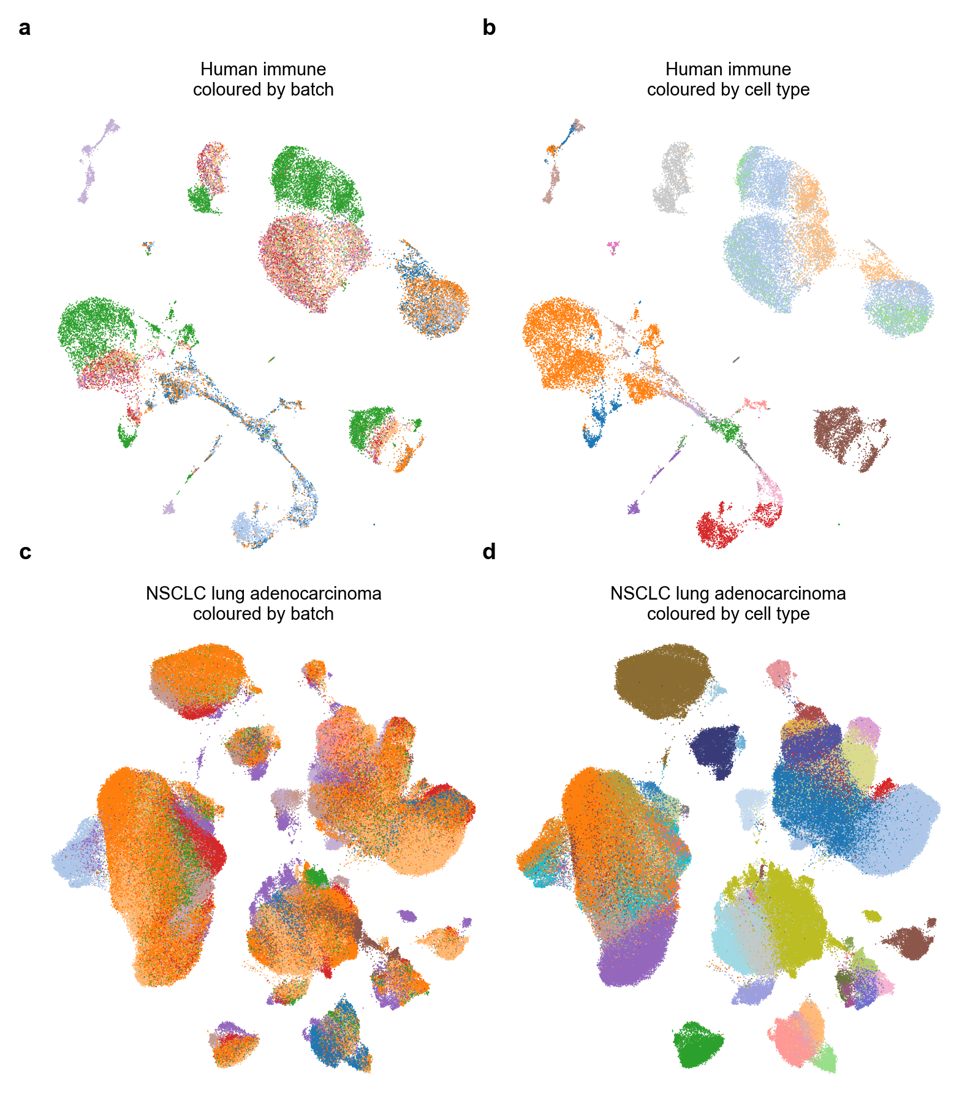

In [22]:
draw(fig_scgpt_umap, "scgpt_umap")